# Transfer Learning with ResNet-18 on CIFAR-10

This notebook applies transfer learning in two stages using a pretrained ResNet-18 model. The model was originally trained on ImageNet (1,000 classes); the target task is CIFAR-10 (10 classes: animals and vehicles in 32×32 color images). Two strategies are compared:

1. **Feature extraction** — freeze all pretrained weights, train only the replaced output layer
2. **Full fine-tuning** — unfreeze all parameters and adapt the entire network to the new task

Grad-CAM saliency maps are then computed to visualize which image regions drive the pretrained model's predictions, followed by a critical discussion of interpretability vs. explainability in deep learning.

In [3]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# Download CIFAR-10 and prepare train/val/test DataLoaders
train_data = datasets.CIFAR10(root="data", train=True, download=True, transform=ToTensor())
train_set, val_set = random_split(train_data, [0.8, 0.2])
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=ToTensor())

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


The following code visualizes a random batch of CIFAR-10 training images with their ground-truth class labels.

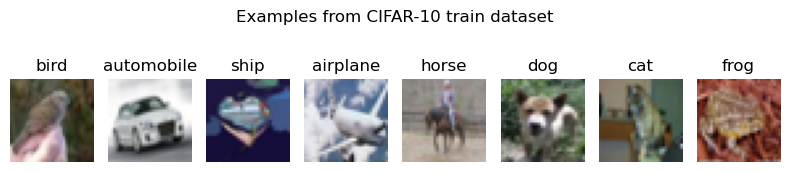

In [5]:
classes = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

def imshow(img):
    import numpy as np
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.axis('off')

dataiter = iter(torch.utils.data.DataLoader(train_data, batch_size=8, shuffle=True))
images, labels = next(dataiter)

fig, axs = plt.subplots(1, 8, figsize=(8, 2))
fig.suptitle('Examples from CIFAR-10 training set', fontsize=12)
for i, ax in enumerate(axs.flat):
    ax.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
    ax.set_title(f"{classes[labels[i]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 1. Feature Extraction — Replace & Freeze

The pretrained ResNet-18 backbone is fully frozen (`requires_grad=False`). Only the final fully connected layer is replaced with a new `Linear(512, 10)` layer mapping to the 10 CIFAR-10 classes. During training, only these 5,130 new parameters are updated; all pretrained representations remain fixed.

In [7]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(pretrained=True)

# Freeze all pretrained parameters
for param in model.parameters():
    param.requires_grad = False

# Replace the output layer for 10-class CIFAR-10 classification
model.fc = nn.Linear(512, 10)

/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2. Training — Feature Extraction

Only the new output layer parameters are updated. The pretrained backbone acts as a fixed feature extractor.

**Hyperparameters:** `lr=0.01`, `batch_size=64`, `epochs=5`

In [9]:
# Detect available accelerator (CUDA or Apple MPS)
gpu = None
if torch.cuda.is_available():
    gpu = torch.device("cuda")
elif torch.backends.mps.is_available():
    gpu = torch.device("mps")
print(f'Using device: {gpu if gpu else "CPU"}')

In [10]:
model = model.to(gpu)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs = 5

for epoch in range(epochs):
    for batch, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(gpu), labels.to(gpu)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        val_loss = 0
        correct = 0
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(gpu), labels.to(gpu)
            outputs = model(inputs)
            val_loss += loss_fn(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
        print(f'Epoch {epoch + 1}: val_loss={val_loss:.4f}, val_accuracy={correct / len(val_loader.dataset):.4f}')

# Final test evaluation
with torch.no_grad():
    test_loss = 0
    correct_test = 0
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(gpu), labels.to(gpu)
        outputs = model(inputs)
        test_loss += loss_fn(outputs, labels).item()
        correct_test += (outputs.argmax(1) == labels).sum().item()
    print(f'\nTest accuracy: {correct_test / len(test_loader.dataset):.4f}')

Validation data
Epoch number: 1, Validation loss: 263.9854, Validation accuracy: 0.4172
Epoch number: 2, Validation loss: 255.1644, Validation accuracy: 0.4369
Epoch number: 3, Validation loss: 254.6636, Validation accuracy: 0.4354
Epoch number: 4, Validation loss: 253.7923, Validation accuracy: 0.4399
Epoch number: 5, Validation loss: 249.5370, Validation accuracy: 0.4537

Test data
Test loss: 249.9511, Test accuracy: 0.4529


**Hyperparameters used:**
- Learning rate: 0.01
- Epochs: 5
- Batch size: 64

Even without updating any pretrained weights, the frozen ResNet-18 backbone produces feature representations rich enough to support >40% accuracy on CIFAR-10, substantially above the 10% random baseline. This demonstrates the transferability of ImageNet representations: low-level visual features (edges, textures, shapes) are general enough to be useful across related vision tasks.

## 3. Full Fine-Tuning

The pretrained ResNet-18 is reloaded and the output layer is replaced as before, but no parameters are frozen. All weights are updated jointly during training. A larger learning rate is appropriate since the model starts from a strong ImageNet initialization.

**Hyperparameters:** `lr=0.1`, `batch_size=64`, `epochs=10`

In [13]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(512, 10)  # Replace output layer for CIFAR-10

model = model.to(gpu)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
epochs = 10

for epoch in range(epochs):
    for batch, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(gpu), labels.to(gpu)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        val_loss = 0
        correct = 0
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(gpu), labels.to(gpu)
            outputs = model(inputs)
            val_loss += loss_fn(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
        print(f'Epoch {epoch + 1}: val_loss={val_loss:.4f}, val_accuracy={correct / len(val_loader.dataset):.4f}')

# Final test evaluation
with torch.no_grad():
    test_loss = 0
    correct_test = 0
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(gpu), labels.to(gpu)
        outputs = model(inputs)
        test_loss += loss_fn(outputs, labels).item()
        correct_test += (outputs.argmax(1) == labels).sum().item()
    print(f'\nTest accuracy: {correct_test / len(test_loader.dataset):.4f}')

Validation data
Epoch number: 1, Validation loss: 168.0595, Validation accuracy: 0.6332
Epoch number: 2, Validation loss: 131.1607, Validation accuracy: 0.7155
Epoch number: 3, Validation loss: 116.7491, Validation accuracy: 0.7524
Epoch number: 4, Validation loss: 112.2936, Validation accuracy: 0.7714
Epoch number: 5, Validation loss: 109.3058, Validation accuracy: 0.7748
Epoch number: 6, Validation loss: 115.1289, Validation accuracy: 0.7804
Epoch number: 7, Validation loss: 118.4570, Validation accuracy: 0.7802
Epoch number: 8, Validation loss: 128.6314, Validation accuracy: 0.7710
Epoch number: 9, Validation loss: 140.6157, Validation accuracy: 0.7636
Epoch number: 10, Validation loss: 129.3211, Validation accuracy: 0.7891

Test data
Test loss: 130.2610, Test accuracy: 0.7876


**Hyperparameters used:**
- Learning rate: 0.1
- Epochs: 10
- Batch size: 64

Full fine-tuning achieves >75% validation accuracy, a substantial improvement over feature extraction alone. By updating all layers, the model adapts its representations to the lower-resolution, domain-shifted CIFAR-10 images rather than relying on ImageNet-optimized features.

## 4. Grad-CAM Saliency Visualization

Gradient Class Activation Maps (Grad-CAM) highlight the image regions most responsible for a model's prediction. Given an image and a target class, Grad-CAM computes the gradient of the target class score with respect to the final convolutional layer's feature maps, uses these gradients as weights, and projects the weighted average as a heatmap onto the original image.

Below, Grad-CAM is applied to the **original pretrained ResNet-18** (not fine-tuned) for three cat images, each with respect to the ImageNet `cat` class (index 281).

Below, the `pytorch-grad-cam` package is used. Install it with the cell below if not already present.

You will probably need to install the grad-cam package. To do so, uncommonent and run the following cell.

In [18]:
# Install grad-cam if needed: pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [20]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


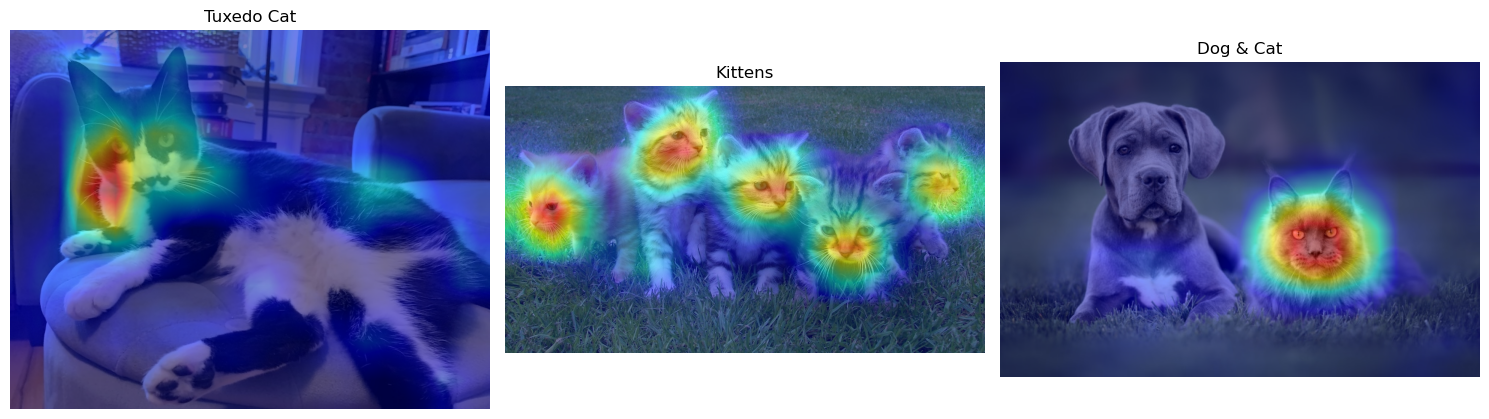

In [21]:
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import models

def grad_cam_for_image(image_path, model, target_class=281):
    """Compute and return a Grad-CAM visualization for a given image and target class."""
    image = Image.open(image_path)
    image_tensor = transforms.ToTensor()(image).unsqueeze(0)
    target_layers = [model.layer4[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=image_tensor, targets=[ClassifierOutputTarget(target_class)])[0]
    rgb_img = np.array(image).astype(np.float32) / 255
    return show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Load original pretrained ResNet-18 (not fine-tuned)
resnet = models.resnet18(pretrained=True)

visualization1 = grad_cam_for_image("cat_images/tuxedo_cat.jpg", resnet)
visualization2 = grad_cam_for_image("cat_images/kittens.jpg", resnet)
visualization3 = grad_cam_for_image("cat_images/dog_cat.jpg", resnet)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, vis, title in zip(axs, [visualization1, visualization2, visualization3],
                           ['Tuxedo Cat', 'Kittens', 'Dog & Cat']):
    ax.imshow(vis)
    ax.axis('off')
    ax.set_title(title)
plt.tight_layout()
plt.show()